# Building an Image Classifier Using the Sequential API

## Load the Fashion MNIST dataset with TensorFlow

In [49]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [50]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [51]:
X_train_full.shape

(60000, 28, 28)

In [52]:
X_test.shape

(10000, 28, 28)

Check the value range:

In [53]:
print('min value: ', np.min(X_train_full[0,:,:]), '; max value: ', np.max(X_train_full[0,:,:]))

min value:  0 ; max value:  255


## Visualization with Colab

Visualize the training data in X_train_full

In [54]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] # there are class names

In [55]:
import matplotlib.pyplot as plt
%matplotlib inline

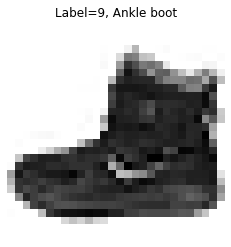

In [56]:
plt.imshow(X_train_full[0], cmap="binary")
plt.axis('off')
plt.title('Label='+str(y_train_full[0])+', '+ class_names[y_train_full[0]])
plt.show()

# Image Classification

## Data Preparation


1) Divide X_train_full into a training set (X_train, y_train) and a validation set (X_valid, y_valid). 

The dataset is already split into a training set and a test set, but there is no validation set, so we’ll create one now. 

2) Since we are going to train the neural network using Gradient Descent, we must scale the input features. For simplicity, we’ll scale the pixel intensities down to the 0–1 range by dividing them by 255.0 (this also converts them to floats)

In [57]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255. # first 5000 samples as valid set
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

In [58]:
X_train.shape

(55000, 28, 28)

In [59]:
y_train.shape

(55000,)

In [60]:
X_valid.shape

(5000, 28, 28)

In [61]:
y_valid.shape

(5000,)

Check the value range:

In [62]:
print('min value: ', np.min(X_train[0,:,:]), '; max value: ', np.max(X_train[0,:,:]))

min value:  0.0 ; max value:  1.0


## Build a Neural Network Model

In [63]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [64]:
# build a model by passing a list of layers.
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [65]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


### Check parameters of a layer

In [66]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [31]:
weights, biases = hidden1.get_weights()

In [67]:
weights

array([[ 0.02448617, -0.00877795, -0.02189048, ..., -0.02766046,
         0.03859074, -0.06889391],
       [ 0.00476504, -0.03105379, -0.0586676 , ...,  0.00602964,
        -0.02763776, -0.04165364],
       [-0.06189284, -0.06901957,  0.07102345, ..., -0.04238207,
         0.07121518, -0.07331658],
       ...,
       [-0.03048757,  0.02155137, -0.05400612, ..., -0.00113463,
         0.00228987,  0.05581069],
       [ 0.07061854, -0.06960931,  0.07038955, ..., -0.00384101,
         0.00034875,  0.02878492],
       [-0.06022581,  0.01577859, -0.02585464, ..., -0.00527829,
         0.00272203, -0.06793761]], dtype=float32)

In [68]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [69]:
biases.shape

(300,)

 Dense Layer:
 * initialized the connection **weights** *randomly*
 * **Biases** initialized to *0*

If you want to use a different initialization method, you can set *kernel_initializer* or *bias_initializer* when creating the layer.

## Compile the Model

Specify the loss function and the optimizer to use.

In [70]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

## Training and Evaluating the Model

In [71]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_data=(X_valid, y_valid))


Epoch 1/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.7237 - accuracy: 0.7643 - val_loss: 0.5213 - val_accuracy: 0.8226
Epoch 2/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4842 - accuracy: 0.8318 - val_loss: 0.4353 - val_accuracy: 0.8526
Epoch 3/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4391 - accuracy: 0.8457 - val_loss: 0.5333 - val_accuracy: 0.7988
Epoch 4/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.4123 - accuracy: 0.8564 - val_loss: 0.3916 - val_accuracy: 0.8650
Epoch 5/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3939 - accuracy: 0.8616 - val_loss: 0.3741 - val_accuracy: 0.8698
Epoch 6/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3751 - accuracy: 0.8678 - val_loss: 0.3706 - val_accuracy: 0.8726
Epoch 7/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3630 - accuracy: 0.8715 - val_loss: 0.3621 - val_accuracy:

### Learning Curve

In [72]:
history_dict = history.history
print(history_dict.keys())
len(history_dict['loss'])

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


30

In [73]:
# if we turn it into a Pandas DataFrame
import pandas as pd
res_df = pd.DataFrame(history_dict)
res_df.head(5)

,loss,accuracy,val_loss,val_accuracy
0,0.723703,0.764309,0.521318,0.8226
1,0.484193,0.831782,0.435322,0.8526
2,0.439053,0.845655,0.533341,0.7988
3,0.412315,0.856364,0.391612,0.8650
4,0.393922,0.861636,0.374081,0.8698


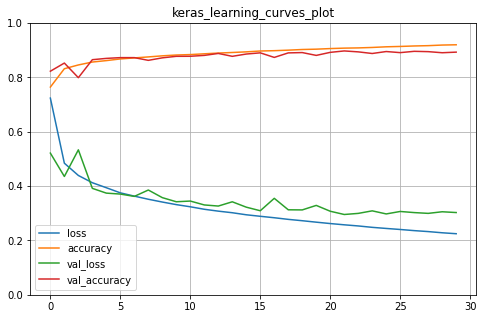

In [74]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("keras_learning_curves_plot")
plt.show()

In [75]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.3366 - accuracy: 0.8820


[0.3366333842277527, 0.8820000290870667]

## Make New Predictions

Use predict() method to make predictions on test set.

In [76]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.03, 0.  , 0.96],
       [0.  , 0.  , 0.99, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [77]:
y_pred = np.argmax(model.predict(X_new), axis=-1)
y_pred

array([9, 2, 1])